In [1]:
import numpy as np 
import pandas as pd
from src import utils, redcells, db
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2
ROOT_PATH = "Z:/data/PROC"
RET_PATH = "D:/retinotopy/aligned_xy/behav"
MDL_PATH = "D:/mouseobj/Passive"

In [2]:
from src.utils import Mouse

In [3]:
def get_retinotopy(mouse, RET_PATH):
    p = Path(RET_PATH).glob('**/*')
    n = "%s_%s" % (mouse.name, mouse.datexp)
    rtpy_file = [x for x in p if x.is_file() if n in x.name][0]
    #rtpy_file = Path(rtpy_file)
    print(f"Loading retinotopy data from {rtpy_file}")
    for file in np.load(rtpy_file, allow_pickle = True).files:
        exec(f"mouse.{file} = np.load(rtpy_file, allow_pickle = True)['{file}']")

from scipy.interpolate import interp1d

def stim_and_mic_time(dat,  spks, tlags = [3.5, 4.5], nplanes = 1):
    # spks is NN by NT
    # tlags at 30 Hz get summed up
    # dat contains the Timeline TL variable

    # this block extracts microscope frame times
    tdaq = dat['TL']['daq']['time']
    tdaq = np.array(tdaq)
    idaq = 80 * (1+np.arange(len(tdaq)))
    ddaq = dat['TL']['daq']['data'].T.flatten()
    ix = (ddaq[1:] < 2) * (ddaq[:-1]>2)
    imic = ix.nonzero()[0]
    imic = imic[:spks.shape[1]*nplanes:nplanes]
    tmic = np.interp(imic, idaq, tdaq)

    
    # the stimulus times and indices, 1-indexed
    istim = dat['TL']['stim']['istim']
    istim = istim.T.flatten()

    tstim = dat['TL']['stim']['time']
    istim = istim[:len(tstim)]#.astype('int32')

    # this interpolates and adds together frames at lag 3.5 and 4.5 from the stimulus
    f = interp1d(tmic, spks, fill_value = 'extrapolate')
    sp = f(tstim + tlags[0]/30 / (24 * 3600)) 
    for j in range(1, len(tlags)):
        sp += f(tstim + tlags[j]/30 / (24 * 3600))

    sp = sp.astype('float32')
    
    return sp, istim

import mat73
import os
def load_timeline(db):    
    mname, datexp, blk = db['mname'], db['datexp'], db['blk']
    root = os.path.join('Z:/data/PROC', mname, datexp, blk)
    fname     = 'Timeline_%s_%s_%s_RAW.mat'%(mname, datexp, blk) 
    fnamepath = os.path.join(root, fname) 
    data = mat73.loadmat(fnamepath)
    return data
        
def signal_variance(sstim, S):
    NN = S.shape[0]
    istim = np.unique(sstim)
    k = 0
    s2 = np.zeros((2, len(istim), NN), 'float32')
    
    for j in range(len(istim)):
        ix = np.nonzero(sstim == istim[j])[0]
        if len(ix) >= 2:
            s2[0, k] = S[:, ix[0]]
            # FIX: Reference S instead of s2
            s2[1, k] = S[:, ix[1]] 
            k += 1
            
    s2 = s2[:, :k]

    ss = s2 - np.mean(s2, 1)[:, np.newaxis, :]
    # FIX: Wrap denominator in parentheses
    ss = ss / (np.mean(ss**2, 1)[:, np.newaxis, :]**.5 + 1e-10) 

    csig = (ss[0] * ss[1]).mean(0)
    print('signal variance is %2.2f' % csig.mean())
    
    if csig.mean() < 0.05:
        print('The signal variance should be at least 0.05 for a normal window with most neurons in visual cortex.')

    return csig, ss


# build mouse

In [58]:
db_ = []
iexp = 1
db_.append({'mname': 'VG56', 'datexp': '2026_07_13', 'blk':'2','stim':'short3'})
db_.append({'mname': 'VG58', 'datexp': '2026_07_14', 'blk':'2','stim':'short3'})
db_.append({'mname': 'VG59', 'datexp': '2026_07_14', 'blk':'2','stim':'short3'})
name, datexp, blk, stim = db_[iexp]['mname'], db_[iexp]['datexp'], db_[iexp]['blk'], db_[iexp]['stim']
print(f"Loading mouse {name} from {datexp} block {blk} stim {stim}")

Loading mouse VG58 from 2026_07_14 block 2 stim short3


In [36]:
m = Mouse(name, datexp, blk, ROOT_PATH)
m.load_neurons_VG(dual_plane=True, return_iscell=True)
get_retinotopy(m, RET_PATH)
green_channel = Path(ROOT_PATH).joinpath(name, datexp, blk, "suite2p")
m.isred = redcells.get_redcells(green_channel)
condition = (m._snr>=.25) & (m._is_cell[:,0].astype(bool))
m.isred = m.isred[condition]
m._spks = m._spks[condition]
m._xpos = m._xpos[condition]
m._ypos = m._ypos[condition]
m._iplane = m._iplane[condition]
m.iarea = m.iarea[condition]
m.iregion = m.iregion[condition]
m.xy_t = m.xy_t[condition]
m._snr = m._snr[condition]

number of recording planes: 20
planes: 20


100%|██████████| 20/20 [03:57<00:00, 11.88s/it]


Loading retinotopy data from D:\retinotopy\aligned_xy\behav\VG59_2026_07_14_2_behav.npz
nrecording_rois: 20
(19398, 2)


In [37]:
dat_TL = load_timeline(db_[iexp])
tlags = [10,11,12,13,14,15,17,18]
csigs = []
from scipy.stats import zscore
for t in tlags:
    S, sstim = stim_and_mic_time(dat_TL, m._spks, nplanes = 1, tlags = [t]) 
    csig, ss = signal_variance(sstim, S)
    csigs.append(csig.mean())
t = np.argmax(csigs) + tlags[0]
print(f"Best lag is {t} frames, with mean signal variance {csigs[t - tlags[0]]:.4f}")
neurons_atframes, m.subset_stim = stim_and_mic_time(dat_TL, m._spks, nplanes = 1, tlags = [t]) 
m.neurons_atframes = zscore(neurons_atframes, axis = 1)
csig, ss = signal_variance(m.subset_stim, m.neurons_atframes)
m.csig = csig

ERROR:root:ERROR: MATLAB type not supported: internal.Serialport, (uint32)
ERROR:root:ERROR: MATLAB type not supported: icomm.mqtt.Client, (uint32)


signal variance is 0.13
signal variance is 0.16
signal variance is 0.18
signal variance is 0.19
signal variance is 0.20
signal variance is 0.21
signal variance is 0.21
signal variance is 0.21
Best lag is 16 frames, with mean signal variance 0.2127
signal variance is 0.21


# check exc and int split

In [38]:
def plot_red_intensity_old(main_root, mname, datexp, blk):
    behav_path = Path(os.path.join(main_root, mname, datexp, blk, 'suite2p'))
    print(f"Loading data from {behav_path}")
    # number of planes (directories) in the suite2p folder
    n_planes = len([name for name in os.listdir(behav_path) if os.path.isdir(os.path.join(behav_path, name))])
    cols = (n_planes + 1) // 2
    fig, ax = plt.subplots(2, cols, figsize=(40, 10))
    ax_flat = ax.flatten()
    for plane in range(n_planes):
        p = f"plane{plane}"
        plane_path = os.path.join(behav_path, p)
        ops = np.load(os.path.join(plane_path, 'ops.npy'), allow_pickle=True).item()
        iscell = np.load(os.path.join(plane_path, 'iscell.npy'), allow_pickle=True)
        redcell = np.load(os.path.join(plane_path, 'redcells.npy'), allow_pickle=True)
        stat = np.load(os.path.join(plane_path, 'stat.npy'), allow_pickle=True)
        nn = redcell.shape[0]
        red_intensity = np.empty((nn))
        meanimage = ops['meanImg_chan2']
        for n in range(0,nn):
            ypix = stat[n]['ypix'][~stat[n]['overlap']]
            xpix = stat[n]['xpix'][~stat[n]['overlap']]
            if len(ypix) > 0:
                red_intensity[n] = meanimage[ypix, xpix].mean()
        red_cells = (iscell[:,0] == 1) & (redcell[:,0] == 1)
        rest_cells = (iscell[:,0] == 1) & (redcell[:,0] == 0)
        ax_flat[plane].hist(red_intensity[red_cells], bins=25, alpha=0.5, label='inhibitory cells', color='tab:red', density=True)
        ax_flat[plane].hist(red_intensity[rest_cells], bins=25, alpha=0.5, label='excitatory cells', color='tab:blue', density=True)
        ax_flat[plane].set_title("plane %d" % (plane))
        ax_flat[plane].set_xlabel("mean red intensity")
    ax[-1,-1].text(0.7, 0.8, f"Excitatory", ha='center', va='center', transform=ax[-1,-1].transAxes, c='tab:blue')
    ax[-1,-1].text(0.7, 0.7, f"Inhibitory", ha='center', va='center', transform=ax[-1,-1].transAxes, c='tab:red')
    ax[0,0].set_ylabel("Density")

In [39]:
import re 
def plot_red_intensity(main_root, mname, datexp, blk):
    behav_path = Path(main_root) / mname / datexp / blk / 'suite2p'
    
    # 1. Filter ONLY for actual plane directories to ensure 'n_planes' is accurate 
    all_items = [name for name in os.listdir(behav_path) if os.path.isdir(os.path.join(behav_path, name))]
    n_planes = len(all_items)
    plane_dirs = sorted([d for d in all_items if d.startswith('plane')], key=lambda x: int(re.search(r'\d+', x).group()))
    if n_planes == 0:
        print("No plane directories found!")
        return

    cols = (n_planes + 1) // 2
    fig, ax = plt.subplots(2, cols, figsize=(40, 10), constrained_layout=True)
    ax_flat = ax.flatten()

    for i, p in enumerate(plane_dirs):
        plane_path = behav_path / p
        
        # Check if files exist before loading
        try:
            ops = np.load(plane_path / 'ops.npy', allow_pickle=True).item()
            iscell = np.load(plane_path / 'iscell.npy', allow_pickle=True)
            redcell = np.load(plane_path / 'redcells.npy', allow_pickle=True)
            stat = np.load(plane_path / 'stat.npy', allow_pickle=True)
        except FileNotFoundError as e:
            print(f"Skipping {p}: Missing file {e}")
            continue

        nn = redcell.shape[0]
        red_intensity = np.zeros(nn)
        meanimage = ops['meanImg_chan2']
        
        for n in range(nn):
            # Using boolean indexing for pixels
            ypix = stat[n]['ypix'][~stat[n]['overlap']]
            xpix = stat[n]['xpix'][~stat[n]['overlap']]
            if len(ypix) > 0:
                red_intensity[n] = meanimage[ypix, xpix].mean()
        
        red_cells = (iscell[:, 0] == 1) & (redcell[:, 0] == 1)
        rest_cells = (iscell[:, 0] == 1) & (redcell[:, 0] == 0)
        
        # Plot to the current axis
        #ax_flat[i].hist(red_intensity[red_cells], bins=25, alpha=0.5, label='Inhibitory', color='tab:red', density=True)
        #ax_flat[i].hist(red_intensity[rest_cells], bins=25, alpha=0.5, label='Excitatory', color='tab:blue', density=True)
        sns.kdeplot(red_intensity[red_cells], ax=ax_flat[i], color='tab:red', label='Inhibitory', fill=True)
        sns.kdeplot(red_intensity[rest_cells], ax=ax_flat[i], color='tab:blue', label='Excitatory', fill=True)
        ax_flat[i].set_title(f"{p}")
        ax_flat[i].set_xlabel("Mean Red Intensity")

C:\Users\labadmin\AppData\Local\Temp\ipykernel_26352\1056476187.py:47: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(red_intensity[red_cells], ax=ax_flat[i], color='tab:red', label='Inhibitory', fill=True)


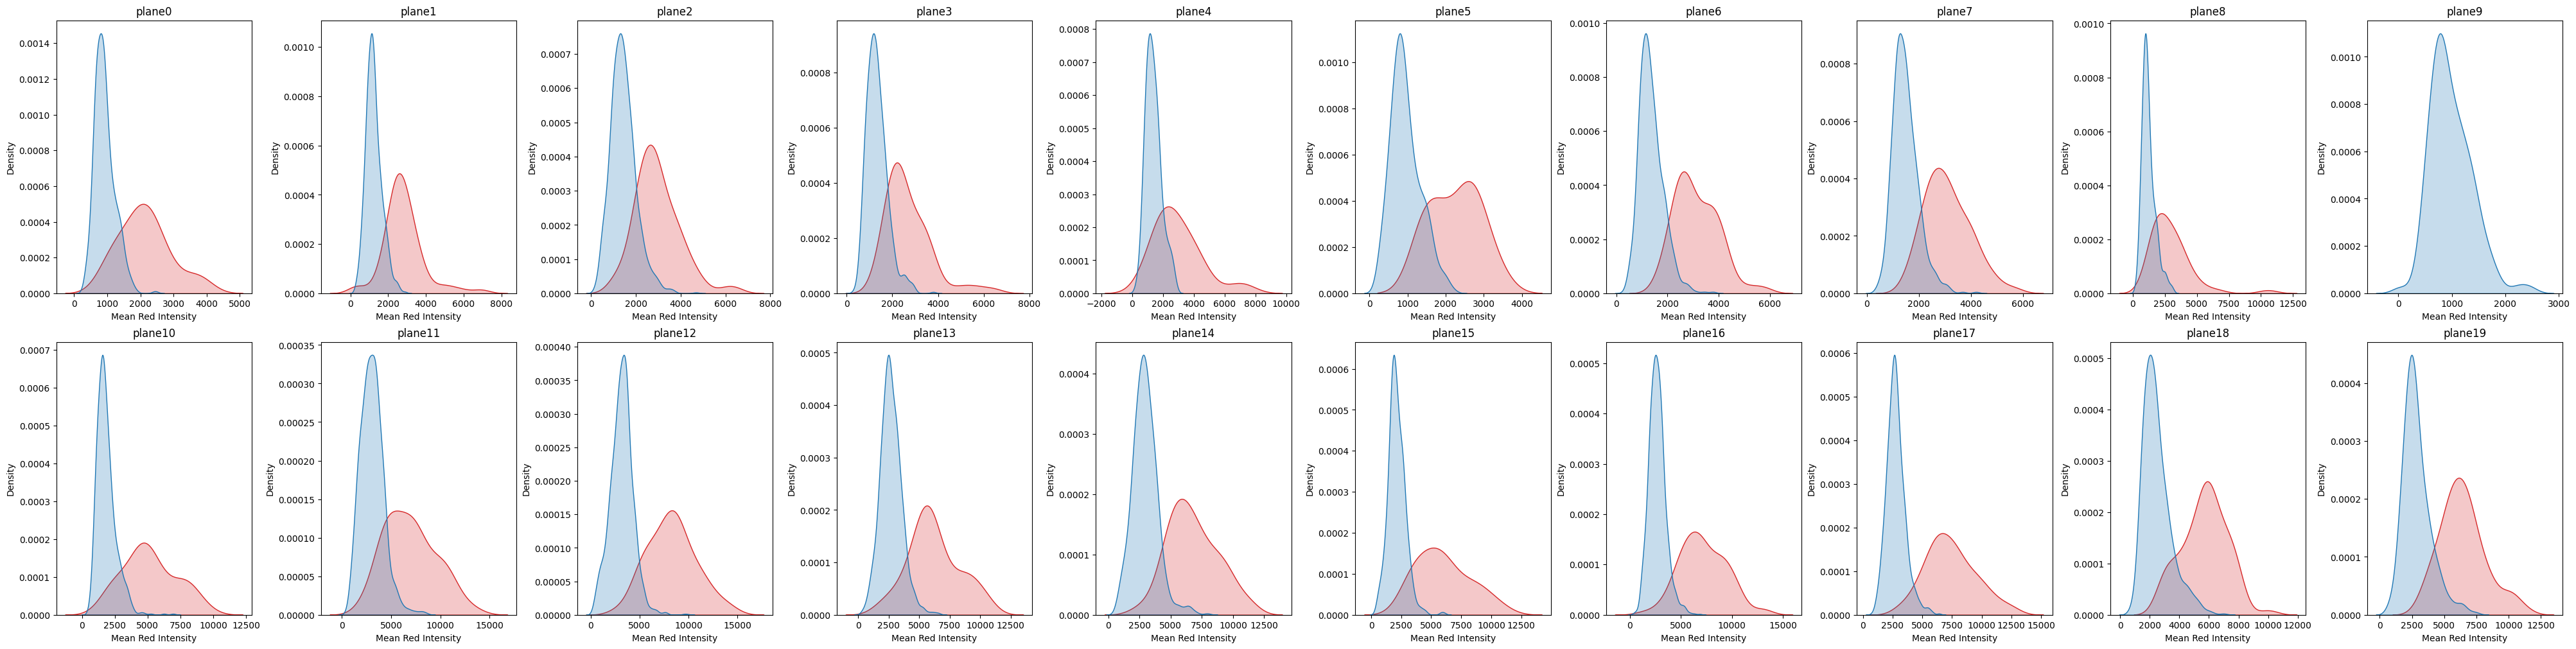

In [57]:
plot_red_intensity(ROOT_PATH, name, datexp, blk)

# check exc and int distribution in depth

In [41]:
sup = (m._iplane < 10)
deep = (m._iplane >= 10)
inter = m.isred[:,0].astype(bool)
exc = ~inter

Total cells above .25 snr: 12024
Superficial: 5631 cells, Deep: 6393 cells
Excitatory: 11404 cells, Inhibitory: 620 cells
-----------------------------------------------------------------
excitatory superficial: 5380 cells, inhibitory superficial: 251 cells
excitatory deep: 6024 cells, inhibitory deep: 369 cells


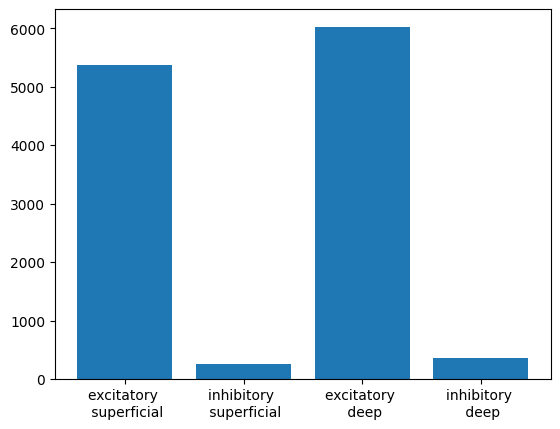

In [42]:
print(f"Total cells above .25 snr: {m._spks.shape[0]}")
print(f"Superficial: {sup.sum()} cells, Deep: {deep.sum()} cells")
print(f"Excitatory: {exc.sum()} cells, Inhibitory: {inter.sum()} cells")
print("-----------------------------------------------------------------")
print(f"excitatory superficial: {(sup & exc).sum()} cells, inhibitory superficial: {(sup & inter).sum()} cells")
print(f"excitatory deep: {(deep & exc).sum()} cells, inhibitory deep: {(deep & inter).sum()} cells")
#plot bars of the intersections
plt.bar(['excitatory \n superficial', 'inhibitory \n superficial', 'excitatory \n deep', 'inhibitory \n deep'],
        [(sup & exc).sum(), (sup & inter).sum(), (deep & exc).sum(), (deep & inter).sum()]);


# get rsm matrices per layer and celltype

In [43]:
from src import invariance

In [44]:
small_areas = np.array([8,0,1,2,9,3,4,5,6,7])
areas_names = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISrll']
n_areas = len(small_areas)
planes = [1,2]
rep_mtx = np.full((n_areas, 2, 2, 32, 32), np.nan)
for i_a, area in enumerate(small_areas):
    for ic, ctype in enumerate(['exc', 'inh']):
        for plane in planes:
            rep_mtx[i_a, ic, plane-1, :, :] = invariance.get_representation_matrix_areas(m, area, plane, ctype, cc_tsh=90) # getting it layer-wise

c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\lib\_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [45]:
def plot_representations(ax, rep_mtx, area: int , layer:int, ctype: int, cbar=False, noylabels = False, noxlabels = False, labelsize=12, Title=None, ytext: tuple =None):
    #labels = create_labels_matrix()
    labels = ["leaves","circles","dryland","rocks","tiles","squares","rleaves","paved"]
    mask = np.eye(32, dtype=bool)
    # 4. Set the background color of the axes to black
    ax.set_facecolor('black')
    #sns.heatmap(rep_mtx[area,layer], cmap='RdBu_r', vmin=-1, vmax=1, center=0, xticklabels=labels, yticklabels=labels, ax=ax, cbar=cbar)
    if layer == -1:
        sns.heatmap(rep_mtx[area], cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax, mask=mask, rasterized=True, cbar=cbar)
    else:
        sns.heatmap(rep_mtx[area, ctype, layer], cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax, mask=mask, rasterized=True, cbar=cbar)
    ax.vlines(np.arange(0,33,4), 0, 32, color = 'k', alpha = .5, linewidth=0.5)
    ax.hlines(np.arange(0,33,4), 0, 32, color = 'k', alpha = .5, linewidth=0.5)
    if noylabels:
        ax.set_yticks([])
    else:
        ax.set_yticks(np.arange(2, 32, 4), labels, fontsize=labelsize, rotation=360)
        ax.tick_params(axis='y', pad=1, length=0)
    if noxlabels:
        ax.set_xticks([])
    else:
        ax.set_xticks(np.arange(2, 32, 4), labels, fontsize=labelsize, rotation=90)
        ax.tick_params(axis='x', pad=1, length=0)

    if Title is not None:
        ax.set_title(Title, fontweight='bold', loc='center', fontsize=12)
    if ytext is not None:
        xpos = ytext[1][0]
        ypos = ytext[1][1]
        ax.text(xpos, ypos, ytext[0], rotation=0, fontsize=12)

Text(0.5, 0.98, "RSM 'deep'")

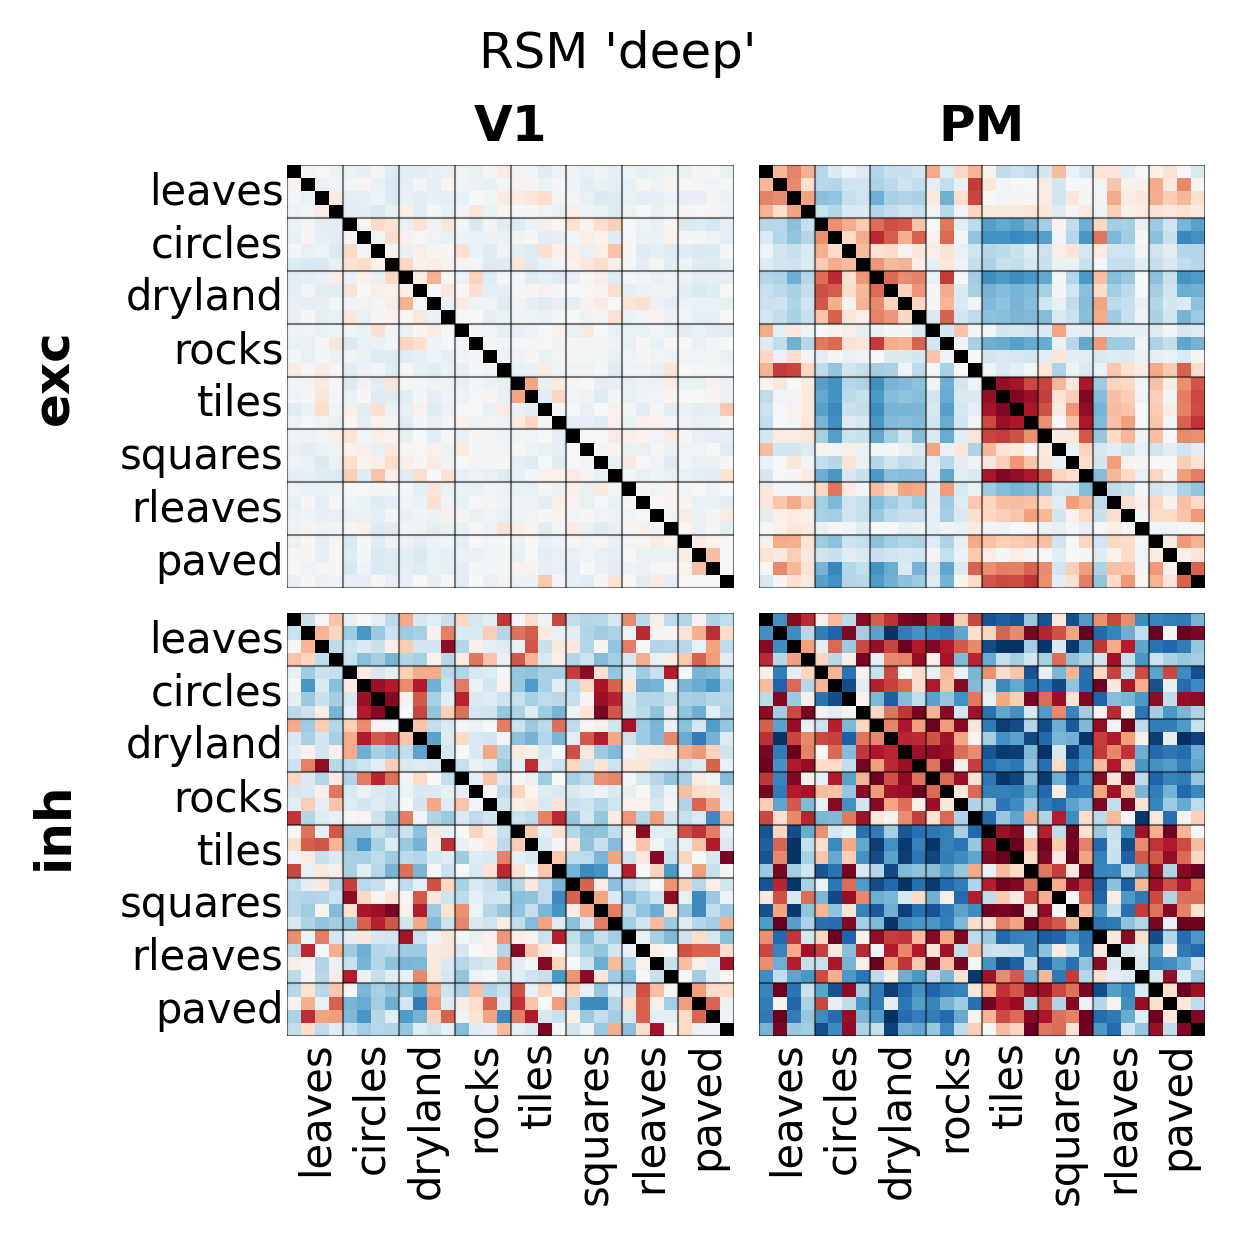

In [46]:
fig, ax = plt.subplots(2,2, figsize=(4,4), dpi=300, constrained_layout=True)
plot_representations(ax[0,0], rep_mtx, area=0, layer=0, ctype=0, cbar=False, noylabels=False, noxlabels=True, labelsize=10, Title="V1")
plot_representations(ax[0,1], rep_mtx, area=1, layer=0, ctype=0, cbar=False, noylabels=True, noxlabels=True, labelsize=10, Title="PM")
plot_representations(ax[1,0], rep_mtx, area=0, layer=0, ctype=1, cbar=False, noylabels=False, noxlabels=False, labelsize=10)
plot_representations(ax[1,1], rep_mtx, area=1, layer=0, ctype=1, cbar=False, noylabels=True, noxlabels=False, labelsize=10)
ax[0,0].set_ylabel("exc", fontsize=12, fontweight='bold', labelpad=10)
ax[1,0].set_ylabel("inh", fontsize=12, fontweight='bold', labelpad=10)
fig.suptitle("RSM 'deep'")

Text(0.5, 0.98, "RSM 'superficial'")

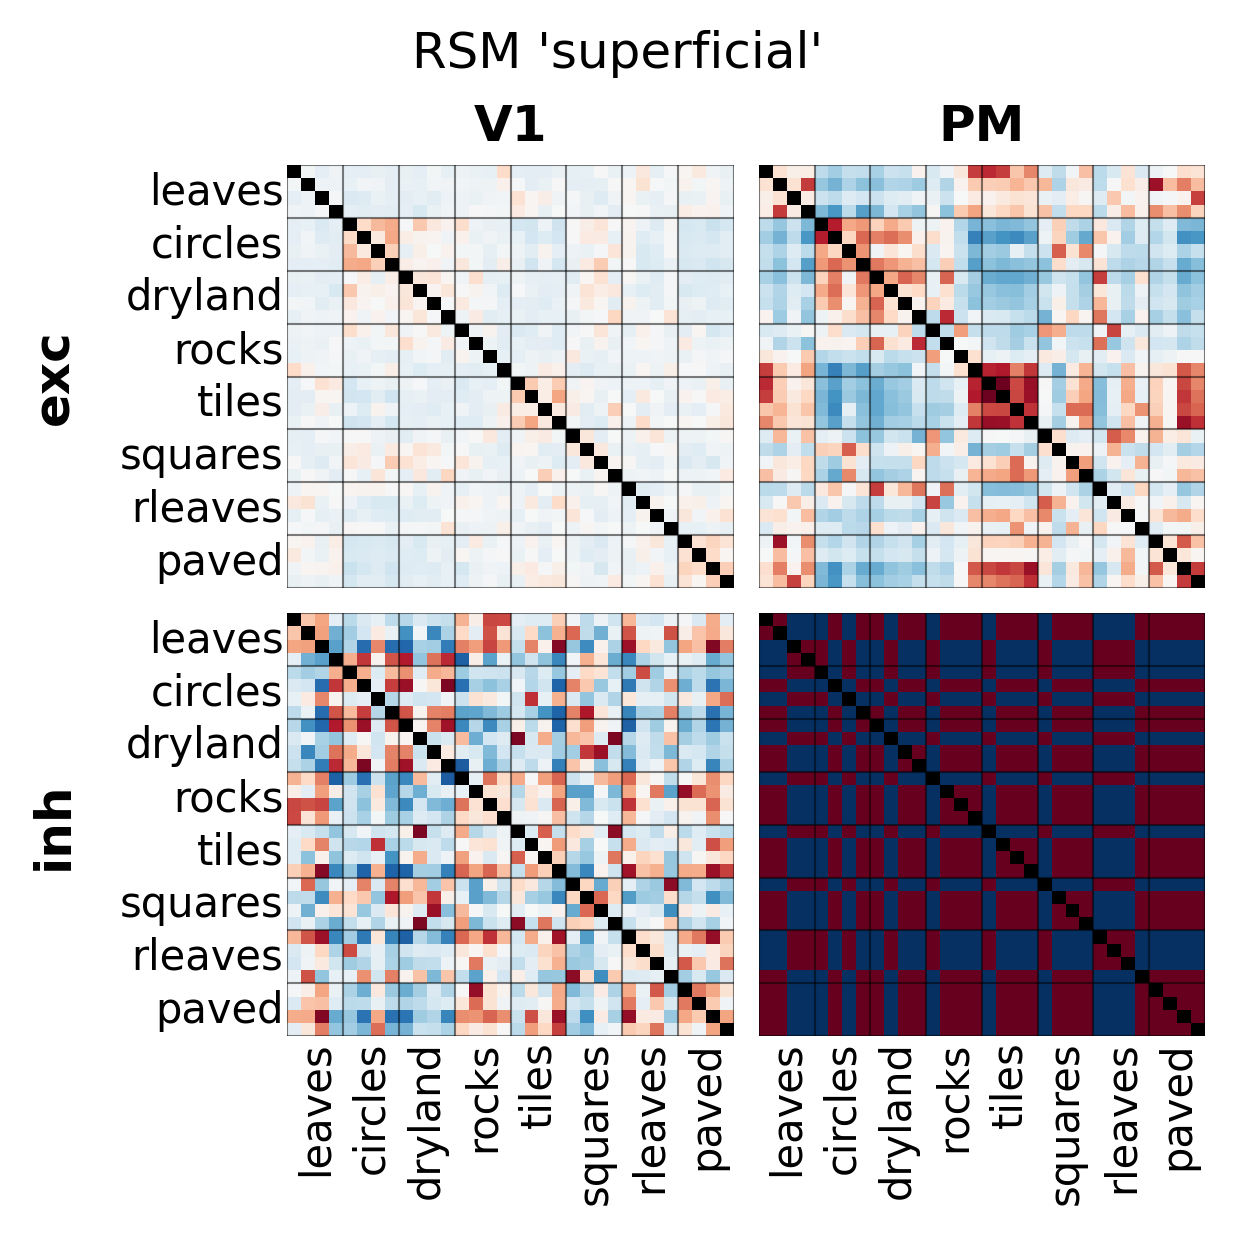

In [47]:
fig, ax = plt.subplots(2,2, figsize=(4,4), dpi=300, constrained_layout=True)
plot_representations(ax[0,0], rep_mtx, area=0, layer=1, ctype=0, cbar=False, noylabels=False, noxlabels=True, labelsize=10, Title="V1")
plot_representations(ax[0,1], rep_mtx, area=1, layer=1, ctype=0, cbar=False, noylabels=True, noxlabels=True, labelsize=10, Title="PM")
plot_representations(ax[1,0], rep_mtx, area=0, layer=1, ctype=1, cbar=False, noylabels=False, noxlabels=False, labelsize=10)
plot_representations(ax[1,1], rep_mtx, area=1, layer=1, ctype=1, cbar=False, noylabels=True, noxlabels=False, labelsize=10)
ax[0,0].set_ylabel("exc", fontsize=12, fontweight='bold', labelpad=10)
ax[1,0].set_ylabel("inh", fontsize=12, fontweight='bold', labelpad=10)
fig.suptitle("RSM 'superficial'")

In [48]:
def get_pair_invariance_df(mtx: np.array):
    cat = ['Leaves', 'Circles', 'Dryland', 'Rocks', 'Tiles', 'Squares', 'Rleaves', 'Paved'] 
    areas = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
    layers = ["deep", "superficial"] 
    ctypes = ["exc", "inh"] # 0 for exc, 1 for inh
    df_pair = pd.DataFrame()
    print(areas)
    for i_a, ar in enumerate(areas):
        for il, layer in enumerate(layers):
            for ic, ctype in enumerate(ctypes):
                df = pd.DataFrame()
                matrix = mtx[i_a, ic, il, :, :]
                condensed = invariance.condense_matrix(matrix, 8, 4)
                a, b = np.triu_indices(8,1)
                positive_cat = []
                negative_cat = []
                invariance_index = []
                for i in zip(a,b):
                    positive_cat.append(cat[i[0]])
                    negative_cat.append(cat[i[1]])
                    invariance_index.append(np.mean([condensed[i[0],i[0]], condensed[i[1],i[1]]]) - condensed[i[0],i[1]])
                df["positive_category"] = np.array(positive_cat)
                df["negative_category"] = np.array(negative_cat)
                df["pair_invariance"] = np.array(invariance_index)
                df["area"] = ar
                df["layer"] = layer
                df["ctype"] = ctype 
                df_pair = pd.concat([df_pair, df])
            df_pair.reset_index(inplace=True, drop=True)
    return df_pair

In [49]:
df = get_pair_invariance_df(rep_mtx)
df_cleaned = df.groupby(["area", "layer", "ctype"])["pair_invariance"].mean().reset_index()
custom_order = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
df_cleaned['area'] = pd.Categorical(df_cleaned['area'], categories=custom_order, ordered=True)
df_cleaned = df_cleaned.sort_values('area')
custom_order = ['superficial', 'deep']
df_cleaned['layer'] = pd.Categorical(df_cleaned['layer'], categories=custom_order, ordered=True)
custom_order = ['exc', 'inh']
df_cleaned['ctype'] = pd.Categorical(df_cleaned['ctype'], categories=custom_order, ordered=True)


['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']


In [50]:
df_cleaned

,area,layer,ctype,pair_invariance
25,VISp,deep,inh,0.100569
26,VISp,superficial,exc,0.108079
27,VISp,superficial,inh,0.170949
24,VISp,deep,exc,0.069082
28,VISpm,deep,exc,0.339925
29,VISpm,deep,inh,0.371307
31,VISpm,superficial,inh,-0.029762
30,VISpm,superficial,exc,0.318003
8,VISam,deep,exc,0.359587
9,VISam,deep,inh,NaN


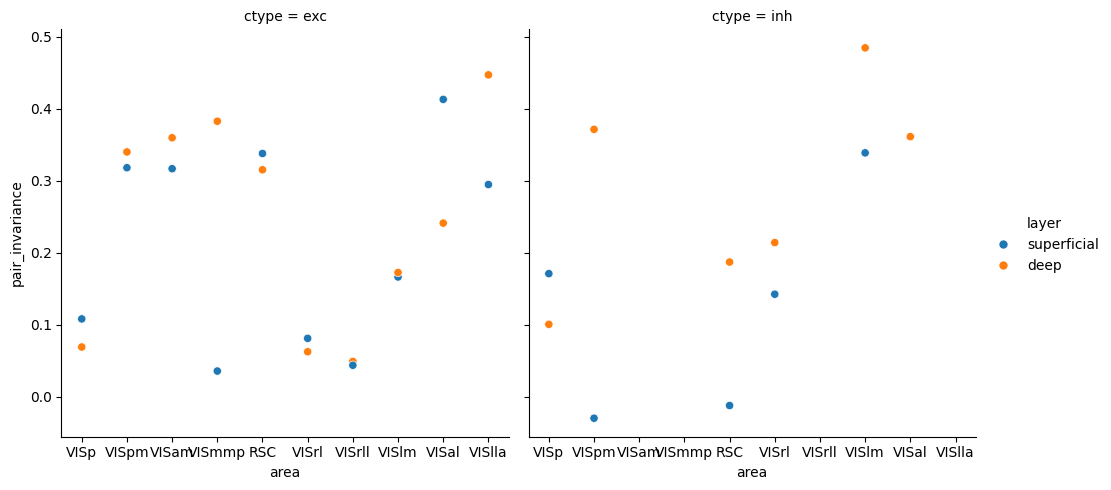

In [51]:
sns.relplot(data=df_cleaned, x='area', y='pair_invariance', hue='layer', col='ctype', legend=True)

In [52]:
all_counts = []
planes = [1, 2]
plane_names = {1: 'deep', 2: 'superficial'}
small_areas = np.array([8,0,1,2,9,3,4,5,6,7])
areas_names = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
for i_a, area in enumerate(small_areas):
    ix_area = np.isin(m.iarea, area)
    for plane in planes:
        if plane == 1:
            ix_plane = (m._iplane >= 10)
        elif plane == 2:
            ix_plane = (m._iplane < 10)
        for ctype in ['exc', 'inh']:
            if ctype == 'exc':
                ix_ctype = ~m.isred[:,0].astype(bool)
            elif ctype == 'inh':
                ix_ctype = m.isred[:,0].astype(bool)
            ix_area_plane = ix_plane & ix_area
            ix_area_plane_ctype = ix_area & ix_plane & ix_ctype
            tsh_area_plane = np.nanpercentile(m.csig[ix_area_plane_ctype], 90)
            cc_sel = (m.csig >= tsh_area_plane)
            ix_sel = ix_area_plane_ctype & cc_sel
            all_counts.append({'mouse': m.name, 
                                'area': areas_names[i_a], 
                                'layer': plane_names[plane], 
                                'ctype': ctype,
                                'area_count': ix_area.sum(),
                                'area_plane_count': ix_area_plane.sum(),
                                'area_plane_ctype_count': ix_area_plane_ctype.sum(),
                                'top10th_percentile': ix_sel.sum()
                                })
df_counts = pd.DataFrame(all_counts)
custom_order = ['VISp', 'VISpm', 'VISam', 'VISmmp', 'RSC', 'VISrl', 'VISrll', 'VISlm', 'VISal', 'VISlla']
df_counts['area'] = pd.Categorical(df_counts['area'], categories=custom_order, ordered=True)
df_counts = df_counts.sort_values('area')
custom_order = ['superficial', 'deep']
df_counts['layer'] = pd.Categorical(df_counts['layer'], categories=custom_order, ordered=True)
custom_order = ['exc', 'inh']
df_counts['ctype'] = pd.Categorical(df_counts['ctype'], categories=custom_order, ordered=True)

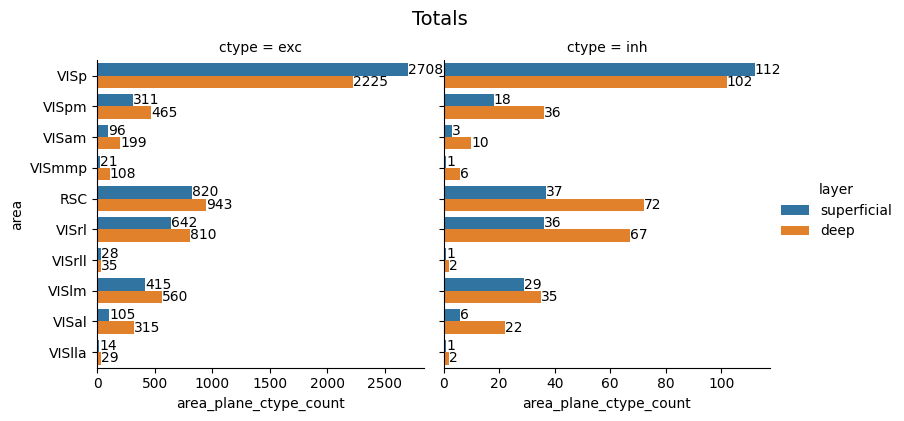

In [53]:
ax = sns.catplot(
    df_counts, kind="bar",
    x="area_plane_ctype_count", y="area", col="ctype", hue="layer",
    height=4, aspect=1, sharex=False
)
for axx in ax.axes[0,:]:
    for cont in axx.containers:
        axx.bar_label(cont, fontsize=10)
ax.figure.suptitle("Totals", fontsize=14, y=1.04);

In [54]:
m.rsm = rep_mtx

In [55]:
utils.save_mouse(m, compressed = False, mdl_path = MDL_PATH)

Creating directory D:\mouseobj\Passive\VG59\2026_07_14\2
Mouse object saved to D:\mouseobj\Passive\VG59\2026_07_14\2
